In [29]:
from pathlib import Path
import numpy as np
import scipy.constants as spc

class DeviceStructure:
    def __init__(self):
        # Physical constants
        self.T = 300
        self.kbT = spc.Boltzmann * self.T
        self.q = spc.e
        self.hbar = spc.hbar

        self.m = 0.45 * spc.m_e

        self.epsl = 8.854e-12 * 3.3
        self.epox = 8.854e-12 * 3.9

        # Geometry parameters
        self.a = 2.5e-10  # discretization spacing (m)
        self.L = 4e-9   # channel length (m)
        self.sd = 2e-9  # source/drain length (m)
        self.sp = 0     # spacer length (m)
        self.tox = 0.5e-9 # thickness of oxide layer
        self.Tch = 5.e-10 # thickness of the channel
        
        self.V_S = 0
        self.V_D = 0

        # Energy grid configuration for transport integration and spectra
        self.energy_min = -1.0  # eV
        self.energy_max = 3.0   # eV
        self.num_energy_points = 2001
        
        # discretization params
        self.NL = int(np.ceil(self.L / self.a)) # total nuumber of atoms in channel 
        self.NSD = int(np.ceil(self.sd / self.a))
        self.NSP = int(np.ceil(self.sp / self.a))
        self.Nx = self.NL + 2 * (self.NSD + self.NSP) # total number of atoms in device (x direction only)
        self.x = np.linspace(0, (self.Nx - 1) * self.a, self.Nx) 

        # DOS parameters
        self.n2d = (2 * self.m * self.kbT) / (self.hbar**2 * np.pi * 2) 
        self.n1d = 2 * np.sqrt(self.m * self.kbT / (self.hbar**2 * np.pi * 2))
        self.Nc = self.n2d

        #hamiltonian
        self.t0 = self.hbar**2/(2*self.m*self.a**2*self.q) # 
        self.H00 = np.array([[2 * self.t0]]) 
        self.H10 = np.array([[-self.t0]]) # coupling energy between leads and channel 
        self.orbitals = 1 # how many orbitals each atom has, for exam
        # Doping profile
        self.NB = 2*self.Nc*np.concatenate([
            np.ones(self.NSD), 
            np.zeros(self.NSP), 
            np.zeros(self.NL), 
            np.zeros(self.NSP), 
            np.ones(self.NSD)])

        # Flat-band voltage and barrier height
        self.VFB, self.phib = 0.35, 0.05
        # Voltage sweeps (more points; ensure requested Vg values are present exactly)
        self.Vds = np.linspace(0.0, 0.8, 17)  # includes 0 V
        Vgs_base = np.linspace(0.0, 0.65, 33)
        Vg_measure = np.array([0.00, 0.04, 0.08, 0.12, 0.16, 0.20, 0.40, 0.65], dtype=float)
        self.Vgs = np.unique(np.round(np.concatenate([Vgs_base, Vg_measure]), 6))
        VV_d = len(self.Vds)
        VV_g = len(self.Vgs)
        self.nn = np.zeros((VV_d, VV_g, self.Nx))
        self.qg = np.zeros((VV_d, VV_g))
        
        # Pre-computed energy grid in Joules for reuse
        self.energy_grid = np.linspace(self.energy_min, self.energy_max, self.num_energy_points)
        self.energy_grid_J = self.energy_grid * self.q

In [30]:
class Helper_functions:
    
    # Define F_1/2(x)
    def FD_half(x):
        '''
        Approximation of the Fermi-Dirac integral of order 1/2.
        Reference: http://dx.doi.org/10.1063/1.4825209
        '''
        x = np.asarray(x, dtype=float)
        v = x**4 + 50 + 33.6 * x * (1 - 0.68 * np.exp(-0.17 * (x + 1)**2))
        return 1 / (np.exp(-x) + 3 * np.pi**0.5 / 4 * v**(-3/8))

    # Define F_-1/2(x) as the derivative of F_1/2(x)
    def FD_minus_half(x):
        x = np.asarray(x, dtype=float)
        dx = np.where(np.abs(x) > 1e-3, np.abs(x) * 1e-6, 1e-9)
        return (Helper_functions.FD_half(x + dx) - Helper_functions.FD_half(x - dx)) / (2 * dx)

    def sparse_diag_product(A, B):
        """
        Compute diagonal elements of C = A * B efficiently for sparse matrices.

        Parameters:
            A (csr_matrix): sparse matrix in CSR format
            B (csc_matrix): sparse matrix in CSC format

        Returns:
            numpy.ndarray: diagonal elements of A*B
        """
        from scipy.sparse import csr_matrix, csc_matrix
        import numpy as np

        # Ensure A is CSR and B is CSC for efficient indexing
        if not isinstance(A, csr_matrix):
            A = csr_matrix(A)
        if not isinstance(B, csc_matrix):
            B = csc_matrix(B)

        n = A.shape[0]
        diag = np.zeros(n, dtype=complex)

        for i in range(n):
            # Get row i from A (CSR format)
            A_row_start, A_row_end = A.indptr[i], A.indptr[i+1]
            A_cols = A.indices[A_row_start:A_row_end]
            A_vals = A.data[A_row_start:A_row_end]

            # Get column i from B (CSC format)
    
            B_rows = B.indices[B.indptr[i]:B.indptr[i+1]]
            B_vals = B.data[B.indptr[i]:B.indptr[i+1]]

            # Compute intersection of indices efficiently
            ptr_a, ptr_b = 0, 0
            sum_diagonal = 0.0
            while ptr_a < len(A_cols) and ptr_b < len(B_rows):
                col_a, row_b = A_cols[ptr_a], B_rows[ptr_b]
                if col_a == row_b:
                    sum_diagonal += A_vals[ptr_a] * B_vals[ptr_b]
                    ptr_a += 1
                    ptr_b += 1
                elif col_a < row_b:
                    ptr_a += 1
                else:
                    ptr_b += 1

            diag[i] = sum_diagonal

        return diag



In [31]:
# Hamiltonian.py
import numpy as np

class Hamiltonian:
    def __init__(self, device_state):
        self.device_state=device_state

    def create_hamiltonian(self, Ec):
        t0=self.device_state.t0
        Nx=self.device_state.Nx
        D2=-2*np.eye(Nx)+np.eye(Nx,k=1)+np.eye(Nx,k=-1)
        
        H=-t0*D2+np.diag(Ec/self.device_state.q) # Ec in Joules converted to eV
        
        self.device_state.H = H
        return H
    
    def print_hamiltonian(self):
        t0=self.device_state.t0
        Nx=self.device_state.Nx
        D2=-2*np.eye(Nx)+np.eye(Nx,k=1)+np.eye(Nx,k=-1)
        
        H=-t0*D2
        
        self.device_state.H = H
        return H
    

            


In [32]:
import numpy as np

class GreensFunction:
    def __init__(self, device_state):
        self.ds=device_state
        self.eta = 1e-12j
    
    def _safe_lead_phase(self, value):
        value_real = np.clip(np.real(value), -1.0 + 1e-12, 1.0 - 1e-12)
        return np.arccos(value_real)
    
    def compute_GF(self,E,H,t0,Ec,Vds): # old way of doing rgf (analytic solution)
        
        Nx=self.ds.Nx; q=self.ds.q; hbar=self.ds.hbar; a=self.ds.a
        
        zplus=1j*1e-12
        
        cos_left = 1-(E+zplus-Ec[0]/q)/(2*t0)
        cos_right = 1-(E+zplus-Ec[-1]/q)/(2*t0)
        
        ka1=self._safe_lead_phase(cos_left)
        ka2=self._safe_lead_phase(cos_right)
        
        sig1=np.zeros((Nx,Nx),dtype=complex); sig1[0,0]=-t0*np.exp(1j*ka1); gam1=1j*(sig1-sig1.conj().T)
        
        sig2=np.zeros((Nx,Nx),dtype=complex); sig2[-1,-1]=-t0*np.exp(1j*ka2); gam2=1j*(sig2-sig2.conj().T)
        
        G=np.linalg.inv((E+zplus)*np.eye(Nx)-H-sig1-sig2)
        A = (E+zplus)*np.eye(Nx)-H-sig1-sig2
       
        #print(sig1, sig2)
        return G,gam1,gam2,sig1,sig2
    
    def rgf(self, E, Ec): #recursive solution based on the 
        E = E + self.eta
        ds = self.ds
        H = ds.H
        dagger = lambda A: np.conjugate(A.T)
        f_s = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - ds.V_S) / (ds.kbT))
        f_d = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - ds.V_D) / (ds.kbT))
        fermi = lambda x,y: 1 / (1 + np.exp((x-y) / (ds.kbT  /ds.q)))
        
        sigmaL,sigmaR = self.self_energy(E,Ec)
        
        self_energy_right = np.zeros_like(H, dtype=complex)
        self_energy_left = np.zeros_like(H, dtype=complex)
        
        self_energy_size = sigmaR.shape[0]
        self_energy_right[-self_energy_size:,-self_energy_size:] = sigmaR
        self_energy_left[0:self_energy_size,0:self_energy_size] = sigmaL
        
        
        gamma1 = 1j * (self_energy_left - dagger(self_energy_left))
        gamma2 = 1j * (self_energy_right - dagger(self_energy_right))
        self_energy_lesser = gamma1 * f_s +  gamma2 * f_d
        
        sigma_less_left = gamma1 * f_s
        sigma_less_right = gamma2 * f_d
        block_size = ds.orbitals
        print(self_energy_left[0,0], self_energy_right[-1,-1])
  
        
        
        N = H.shape[0]
        num_blocks = N // block_size
        
        E_matrix = np.eye(N, dtype=complex) * (E)
        A = E_matrix - H - self_energy_left - self_energy_right
        
        
        # Initialize arrays (this style of storing data was taken from jiezi program)
        g_R_blocks = []
        g_lesser_blocks = []

        
        G_R = [None] * num_blocks
        G_R_1 = [None] * (num_blocks - 1)
        G_lesser = [None] * num_blocks
        G_lesser_1 = [None] * (num_blocks - 1)
        
        # Forward recursion: Calculate diagonal blocks of g_R
        for i in range(num_blocks):
            start = i * block_size
            end = (i+1) * block_size
            prev = (i - 1) * block_size
            if i == 0:
                # First block
                g_0_r = np.linalg.inv(A[start:end, start:end])
                g_R_blocks.append(g_0_r)
                #g_lesser
                g_0_lesser = g_0_r @ self_energy_lesser[start:end, start:end] @ dagger(g_0_r)
                g_lesser_blocks.append(g_0_lesser)
            else:          
                
                H_eff = A[start:end, start:end] - A[start:end, prev:start] @ g_R_blocks[i-1] @ A[prev:start, start:end]
                g_R_blocks.append(np.linalg.inv(H_eff))

                #g_i_lesser calculation
                sigma_lesser = A[start:end, prev:start] @ g_lesser_blocks[i - 1] @ dagger(A[prev:start, start:end])
                g_i_lesser = g_R_blocks[i] @ (self_energy_lesser[start: end, start: end] + sigma_lesser - \
                    self_energy_lesser[start:end, prev:start] @ dagger(g_R_blocks[i - 1]) @ dagger(A[prev:start, start:end]) - \
                        A[start:end, prev:start] @ g_R_blocks[i-1] @ self_energy_lesser[prev:start, start:end]) @ dagger(g_R_blocks[i])
                g_lesser_blocks.append(g_i_lesser)        

        G_R[-1] = g_R_blocks[-1]
        G_lesser[-1] = g_lesser_blocks[-1]

        for i in reversed(range(num_blocks - 1)):
            start = i * block_size
            end = (i+1)*block_size
            after = (i+2)*block_size

            
            # Dyson equation for current block
            G_R[i] = g_R_blocks[i] @ (np.eye(block_size) + 
            A[start:end, end:after]@G_R[i+1]@A[end:after, start:end]@g_R_blocks[i])
            
            G_R_1[i] = -G_R[i + 1] @ A[end:after, start:end] @ g_R_blocks[i]
            
        
            #lesser function
            
            gr0 = np.linalg.inv(E * np.eye(block_size) - H[start:end, start:end]) 
            ga0 = dagger(gr0)
            gr1 = np.linalg.inv(E * np.eye(block_size) - H[end:after, end:after])
            ga1 = dagger(gr1)
            gqq1 = gr0 @ self_energy_lesser[start:end, end:after] @ ga1
            gq1q = gr1 @ self_energy_lesser[end:after, start:end] @ ga0 
            
            G_i_lesser = g_lesser_blocks[i] + g_R_blocks[i] @ (A[start:end, end:after] @ G_lesser[i + 1] @ dagger(A[end:after, start:end])) @ dagger(g_R_blocks[i]) - \
                (g_lesser_blocks[i] @ A[end:after, start:end] @ dagger(G_R_1[i].T) + G_R_1[i].T @ A[end:after, start:end] @ g_lesser_blocks[i]) - \
                    (gqq1 @ dagger(A[end:after, start:end]) @ dagger(G_R[i]) + G_R[i] @ A[start:end, end:after] @ gq1q)
            
            G_lesser[i] = G_i_lesser
            
            G_i_lesser_1 = gq1q - G_R_1[i] @ A[start:end, end:after] @ gq1q - G_R[i+1] @ A[end:after,start:end] @ g_lesser_blocks[i] - \
                G_lesser[i+1] @ dagger(A[end:after,start:end]) @ dagger(g_R_blocks[i])
            
            G_lesser_1[i] = G_i_lesser_1[0]
            
            
        G_R = np.diag(np.ravel(G_R).flatten())
        G_lesser = np.diag(np.ravel(G_lesser).flatten())
    
        return G_R, G_lesser, gamma1, gamma2, sigma_less_left, sigma_less_right
    
    
        """diagonals = [np.diag(block) for block in G_lesser]  # Extract diagonals 
        G_lesser = np.concatenate(diagonals, dtype=complex)  # Concatenate all diagonals 

        diagonals = [np.diag(block) for block in G_R]  # Extract diagonals 
        G_R = np.concatenate(diagonals, dtype=complex)  # Concatenate all diagonals 
        
        return G_R, G_lesser, gamma1, gamma2, sigma_less_left, sigma_less_right"""
    
    def surface_gf(self, Energy, tol=1e-6): #right now this is only tested for 1D
        device_state = self.ds
        Energy = Energy
        H00 = device_state.H00
        H10 = device_state.H10
        dagger = lambda A: np.conjugate(A.T)
        I = np.eye(H00.shape[0], dtype=complex)
        H01 = dagger(H10)
        
        epsilon_s = H00.copy()
        epsilon = H00.copy()
        alpha = H01.copy()
        beta = dagger(H10).copy()
        err = 1.0
        
        while err > tol:
            inv_E = np.linalg.inv(Energy * I - epsilon)
            epsilon_s_new = epsilon_s + alpha @ inv_E @ beta
            epsilon_new = epsilon + beta @ inv_E @ alpha + alpha @ inv_E @ beta
            alpha_new = alpha @ inv_E @ alpha
            beta_new = beta @ inv_E @ beta
            
            err = np.linalg.norm(alpha_new, ord='fro')
            
            epsilon_s, epsilon, alpha, beta = epsilon_s_new, epsilon_new, alpha_new, beta_new
        
        return np.linalg.inv(Energy * I - epsilon_s)
    def self_energy(self, E, Ec):
        dagger = lambda A: A.conj().T
        
        # Surface Green's functions at left and right leads
        
        G_surf_left = self.surface_gf(E - Ec[0] / self.ds.q)
        G_surf_right = self.surface_gf(E - Ec[-1] / self.ds.q)
        
        # Coupling matrices
        H10 = self.ds.H10
        H01 = dagger(H10)
        
        # Self-energy calculation (Σ = τ g τ†)
        sigma_left = H01 @ G_surf_left @ H10
        sigma_right = H10 @ G_surf_right @ H01
        #print(sigma_left, sigma_right)
        return sigma_left, sigma_right


In [33]:
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh

from solver import NonlinearPoissonSolver, VACUUM_PERMITTIVITY

class PoissonSolver:
    """
    FEM Poisson wrapper replicating the legacy finite-difference model.
    """

    def __init__(self, device_state):
        self.ds = device_state
        self._comm = MPI.COMM_SELF
        length = (self.ds.Nx - 1) * self.ds.a
        self._domain = mesh.create_interval(self._comm, self.ds.Nx - 1, [0.0, length])
        eps_r = self.ds.epsl / VACUUM_PERMITTIVITY

        channel_start = self.ds.NSD + self.ds.NSP
        channel_end = channel_start + self.ds.NL
        self._gate_mask = np.zeros(self.ds.Nx, dtype=float)
        self._gate_mask[channel_start:channel_end] = 1.0
        self._gate_coeff = 2.0 * self.ds.epox / (self.ds.tox * self.ds.Tch)
        self._electron_coeff = -self.ds.q / self.ds.a

        self._solver = NonlinearPoissonSolver(
            domain=self._domain,
            permittivity=eps_r,
            dirichlet_bcs=[],
            degree=1,
            eps0=VACUUM_PERMITTIVITY,
        )

        nullspace = PETSc.NullSpace().create(constant=True)
        self._nullspace = nullspace
        for mat in (self._solver.K, self._solver.P):
            mat.setNullSpace(nullspace)
            set_tns = getattr(mat, "setTransposeNullSpace", None)
            if set_tns is not None:
                set_tns(nullspace)

        dof_coords = self._solver._dof_coords[:, 0]
        dof_index = np.rint(dof_coords / self.ds.a).astype(int)
        self._dof_index = np.clip(dof_index, 0, self.ds.Nx - 1)
        self._nb_dof = self.ds.NB[self._dof_index].copy()
        self._gate_mask_dof = self._gate_mask[self._dof_index].copy()
        self._gate_profile = np.zeros(self.ds.Nx, dtype=float)
        self._gate_profile_dof = self._gate_profile[self._dof_index].copy()
        self._last_phi: np.ndarray | None = None

        self._D2p = self._build_fd_operator()
        self._fd_B = -self.ds.q**2 * self.ds.a / self.ds.epsl
        self._fd_gate_coeff = (2.0 * self.ds.q * self.ds.epox * self.ds.a**2) / (self.ds.epsl * self.ds.tox * self.ds.Tch)
        self.fd_residual_history: list[float] = []

    def _left_boundary(self, x):
        return np.isclose(x[0], 0.0)

    def _right_boundary(self, x):
        return np.isclose(x[0], (self.ds.Nx - 1) * self.ds.a)

    def fermi_dirac(self, eta):
        eta = np.asarray(eta, dtype=float)
        return np.log1p(np.exp(-np.abs(eta))) + np.maximum(eta, 0.0)

    def _carrier_density(self, eta):
        return self.ds.Nc * self.fermi_dirac(eta)

    def _update_gate_profile(self, Vg):
        self._gate_profile[:] = Vg
        self._gate_profile_dof = self._gate_profile[self._dof_index]

    def _update_boundary_conditions(self):
        return None

    def _make_charge_callback(self, Efn_dof):
        q_over_a = self._electron_coeff
        gate_coeff = self._gate_coeff
        gate_mask = self._gate_mask_dof
        gate_profile = self._gate_profile_dof
        nb_dof = self._nb_dof
        kbT = self.ds.kbT

        def charge_callback(potential, coords):
            phi = potential
            Ec = -self.ds.q * phi
            eta = (Efn_dof - Ec) / kbT
            n0 = self._carrier_density(eta)
            rho_elec = q_over_a * (n0 - nb_dof)
            rho_gate = gate_coeff * gate_mask * (gate_profile - phi)
            return rho_elec + rho_gate

        return charge_callback

    def solve_poisson(self, Vg, Efn):
        Vg = np.asarray(Vg, dtype=float)
        Efn = np.asarray(Efn, dtype=float)

        self._update_gate_profile(Vg)
        self._update_boundary_conditions()

        Efn_dof = Efn[self._dof_index]
        self._solver.set_charge_callback(self._make_charge_callback(Efn_dof))

        if self._last_phi is None:
            initial_phi = -Efn_dof / self.ds.q
        else:
            initial_phi = self._last_phi

        result = self._solver.solve(initial_guess=initial_phi)
        phi = result.potential.x.array.copy()
        self._last_phi = phi

        Ec = -self.ds.q * phi
        eta_final = (Efn - Ec) / self.ds.kbT
        n0 = self._carrier_density(eta_final)

        self._record_fd_residual(Ec, n0, Vg)
        return Ec, n0

    def _record_fd_residual(self, Ec, n0, Vg):
        rhs = self._fd_B * (n0 - self.ds.NB) + self._fd_gate_coeff * Vg
        residual = self._D2p @ Ec - rhs
        max_res = float(np.max(np.abs(residual)))
        self.fd_residual_history.append(max_res)

    def _build_fd_operator(self):
        Nx = self.ds.Nx
        D2 = -2.0 * np.eye(Nx)
        idx = np.arange(Nx - 1)
        D2[idx, idx + 1] = 1.0
        D2[idx + 1, idx] = 1.0
        D2y = np.zeros(Nx, dtype=float)
        channel_start = self.ds.NSD + self.ds.NSP
        channel_end = channel_start + self.ds.NL
        factor = -2.0 * self.ds.epox * self.ds.a**2 / (self.ds.epsl * self.ds.tox * self.ds.Tch)
        D2y[channel_start:channel_end] = factor
        D2p = D2 + np.diag(D2y)
        D2p[0, 0] = -1.0
        D2p[-1, -1] = -1.0
        return D2p

In [34]:
import os
import multiprocessing as mp

import numpy as np
import scipy.constants as spc

# Keep BLAS from over-threading inside each process
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# Global pool handle (used by _get_pool)
_MP_POOL = None


def _fd_half(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    v = x**4 + 50.0 + 33.6 * x * (1.0 - 0.68 * np.exp(-0.17 * (x + 1.0) ** 2))
    return 1.0 / (np.exp(-x) + 3.0 * np.sqrt(np.pi) / 4.0 * v ** (-3.0 / 8.0))


def _fd_minus_half(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    dx = np.where(np.abs(x) > 1e-3, np.abs(x) * 1e-6, 1e-9)
    return (_fd_half(x + dx) - _fd_half(x - dx)) / (2.0 * dx)


def _compute_gf_direct(
    E: float,
    H: np.ndarray,
    t0: float,
    Ec_J: np.ndarray,
    Vds: float,
    q: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    zplus = 1j * 1e-12
    Ec_eV = Ec_J / q

    cos_left = 1.0 - (E + zplus - Ec_eV[0]) / (2.0 * t0)
    cos_right = 1.0 - (E + zplus - Ec_eV[-1]) / (2.0 * t0)

    ka1 = np.arccos(np.clip(np.real(cos_left), -1.0 + 1e-12, 1.0 - 1e-12))
    ka2 = np.arccos(np.clip(np.real(cos_right), -1.0 + 1e-12, 1.0 - 1e-12))

    Nx = H.shape[0]
    sig1 = np.zeros((Nx, Nx), dtype=complex)
    sig2 = np.zeros((Nx, Nx), dtype=complex)
    sig1[0, 0] = -t0 * np.exp(1j * ka1)
    sig2[-1, -1] = -t0 * np.exp(1j * ka2)

    gam1 = 1j * (sig1 - sig1.conj().T)
    gam2 = 1j * (sig2 - sig2.conj().T)

    A = (E + zplus) * np.eye(Nx) - H - sig1 - sig2
    G = np.linalg.inv(A)

    return G, gam1, gam2


def _negf_direct_chunk(
    energies: np.ndarray,
    H: np.ndarray,
    t0: float,
    Ec_J: np.ndarray,
    Vd: float,
    n1d: float,
    kbT: float,
    q: float,
    hbar: float,
    a: float,
    dE: float,
) -> tuple[float, np.ndarray]:
    mu_s, mu_d = 0.0, -float(Vd)

    I_sum = 0.0
    n_sum = np.zeros(H.shape[0], dtype=float)

    pref_I = dE * (q**2 / (np.pi * hbar))
    pref_n = dE / (a * np.pi)

    for E in np.asarray(energies, dtype=float):
        f_s = n1d * _fd_minus_half(-q * (E - mu_s) / kbT)
        f_d = n1d * _fd_minus_half(-q * (E - mu_d) / kbT)

        G_R, gamma_s, gamma_d = _compute_gf_direct(float(E), H, t0, Ec_J, float(Vd), q)
        T = float(np.real(np.trace(gamma_s @ G_R @ gamma_d @ G_R.conj().T)))

        I_sum += pref_I * T * (f_s - f_d)

        A_s = G_R @ gamma_s @ G_R.conj().T
        A_d = G_R @ gamma_d @ G_R.conj().T
        Gn = A_s * f_s + A_d * f_d

        n_sum += pref_n * np.real(np.diag(Gn))

    return I_sum, n_sum




def _get_pool(nproc: int):
    global _MP_POOL

    if _MP_POOL is None:
        try:
            ctx = mp.get_context("fork")
        except Exception:
            ctx = mp

        _MP_POOL = ctx.Pool(processes=int(nproc))

    return _MP_POOL


class MainSolver:
    def __init__(self):
        self.ds = DeviceStructure()
        self.ham = Hamiltonian(self.ds)
        self.gf = GreensFunction(self.ds)
        self.ps = PoissonSolver(self.ds)

        self.RGF = False
        self.energy_grid = None

        self.use_multiprocessing = True
        self.mp_processes = 16

    def solve(self):
        ds = self.ds
        VV_d = len(ds.Vds)
        VV_g = len(ds.Vgs)

        ds.II = np.zeros((VV_d, VV_g))
        ds.nn = np.zeros((VV_d, VV_g, ds.Nx))
        ds.EEc = np.zeros((VV_d, VV_g, ds.Nx))
        ds.EFn = np.zeros((VV_d, VV_g, ds.Nx))

        for i, Vd in enumerate(ds.Vds):
            for j, Vg_val in enumerate(ds.Vgs):
                print(f"Solving for Vd={Vd:.3f} Vg={Vg_val:.3f}")

                Vg = np.concatenate(
                    [
                        np.zeros(ds.NSD + ds.NSP),
                        (Vg_val - ds.VFB) * np.ones(ds.NL),
                        np.zeros(ds.NSD + ds.NSP),
                    ]
                )

                if j == 0:
                    Efn = ds.q * np.concatenate(
                        [
                            np.zeros(ds.NSD + ds.NSP),
                            -Vd * np.ones(ds.NL),
                            -Vd * np.ones(ds.NSD + ds.NSP),
                        ]
                    )
                    Ec, _ = self.ps.solve_poisson(Vg, Efn)
                else:
                    Ec = ds.EEc[i, j - 1, :].copy()

                mu_s, mu_d = 0.0, -Vd
                ds.V_S = mu_s
                ds.V_D = mu_d

                error_current = 1.0
                max_iter = 100
                iteration = 0

                n_tot = np.zeros(ds.Nx)
                I_total_prev = 0.0

                while error_current > 1e-3 and iteration < max_iter:
                    Ec_new, _ = self.ps.solve_poisson(Vg, Efn)
                    H = self.ham.create_hamiltonian(Ec_new)

                    I_total, n_tot_new = self.compute_current_and_density(H, Ec_new, Vd)
                    error_current = abs(I_total - I_total_prev) / (abs(I_total) + 1e-12)

                    # Update quasi-Fermi level using the same 2D FD relation as Poisson:
                    # n/Nc = log(1 + exp(eta)), eta = (Efn - Ec)/(kT)
                    with np.errstate(over="ignore", invalid="ignore"):
                        n_over_Nc = np.clip(n_tot_new / ds.Nc, 0.0, None)
                        eta = np.empty_like(n_over_Nc)
                        large = n_over_Nc > 50.0
                        eta[large] = n_over_Nc[large]
                        eta[~large] = np.log(np.expm1(n_over_Nc[~large]) + 1e-300)
                        Efn_new = Ec_new + ds.kbT * eta

                    Ec[:] = Ec_new.copy()
                    Efn[:] = Efn_new.copy()
                    n_tot[:] = n_tot_new.copy()

                    I_total_prev = I_total
                    iteration += 1

                ds.II[i, j] = I_total
                ds.nn[i, j, :] = n_tot.copy()
                ds.EEc[i, j, :] = Ec.copy()
                ds.EFn[i, j, :] = Efn.copy()

                print(
                    f"Converged: Iterations={iteration}, Relative Current Error={error_current:.3e}, "
                    f"Current={I_total:.3e} A"
                )

    def compute_current_and_density(self, H, Ec, Vd):
        """Compute current and carrier density via NEGF."""
        ds = self.ds
        energy_grid = ds.energy_grid
        dE = float(energy_grid[1] - energy_grid[0])

        self.energy_grid = energy_grid

        mu_s, mu_d = 0.0, -float(Vd)
        I_total = 0.0
        n_tot_new = np.zeros(ds.Nx)

        if self.RGF:
            for E in energy_grid:
                f_s = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - mu_s) / (ds.kbT))
                f_d = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - mu_d) / (ds.kbT))

                G_R, G_lesser, gamma_s, gamma_d, sigma_less_left, sigma_less_right = self.gf.rgf(E, Ec)
                A_matrix = 1j * (G_R - MainSolver.dagger(G_R))

                IL_contrib = np.real(np.sum(Helper_functions.sparse_diag_product(sigma_less_left, A_matrix))) - np.real(
                    np.sum(Helper_functions.sparse_diag_product(gamma_s, G_lesser))
                )
                IR_contrib = np.real(np.sum(Helper_functions.sparse_diag_product(sigma_less_right, A_matrix))) - np.real(
                    np.sum(Helper_functions.sparse_diag_product(gamma_d, G_lesser))
                )

                I_total += dE * (ds.q**2 / (2 * np.pi * spc.hbar)) * (IL_contrib - IR_contrib)
                n_tot_new += dE / (ds.a * np.pi) * np.real(np.diag(G_lesser))

            return I_total, n_tot_new

        if self.use_multiprocessing and int(self.mp_processes) > 1:
            pool = _get_pool(int(self.mp_processes))
            chunks = np.array_split(energy_grid, int(self.mp_processes))

            args = [
                (
                    c,
                    H,
                    ds.t0,
                    Ec,
                    float(Vd),
                    float(ds.n1d),
                    float(ds.kbT),
                    float(ds.q),
                    float(ds.hbar),
                    float(ds.a),
                    dE,
                )
                for c in chunks
                if c.size > 0
            ]

            results = pool.starmap(_negf_direct_chunk, args)
            I_total = float(sum(r[0] for r in results))
            for _, n_chunk in results:
                n_tot_new += n_chunk

            return I_total, n_tot_new

        # Serial fallback
        for E in energy_grid:
            f_s = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - mu_s) / (ds.kbT))
            f_d = ds.n1d * Helper_functions.FD_minus_half(-ds.q * (E - mu_d) / (ds.kbT))

            G_R, gamma_s, gamma_d, _, _ = self.gf.compute_GF(E, H, ds.t0, Ec, Vd)
            T = float(np.real(np.trace(gamma_s @ G_R @ gamma_d @ G_R.conj().T)))

            I_total += dE * (ds.q**2 / (np.pi * ds.hbar)) * T * (f_s - f_d)

            A_s = G_R @ gamma_s @ G_R.conj().T
            A_d = G_R @ gamma_d @ G_R.conj().T
            Gn = A_s * f_s + A_d * f_d

            n_tot_new += dE / (ds.a * np.pi) * np.real(np.diag(Gn))

        return I_total, n_tot_new

    @staticmethod
    def dagger(A):
        return A.conj().T


solver_instance = MainSolver()
solver_instance.solve()


Solving for Vd=0.000 Vg=0.000


Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - 

Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.020
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.040
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.041
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.061
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.080
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.081
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.102
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.120
Converged: Iterations=1, Relative Current Error=0.000e+00, Current=0.000e+00 A
Solving for Vd=0.000 Vg=0.122
Converged: Iteratio

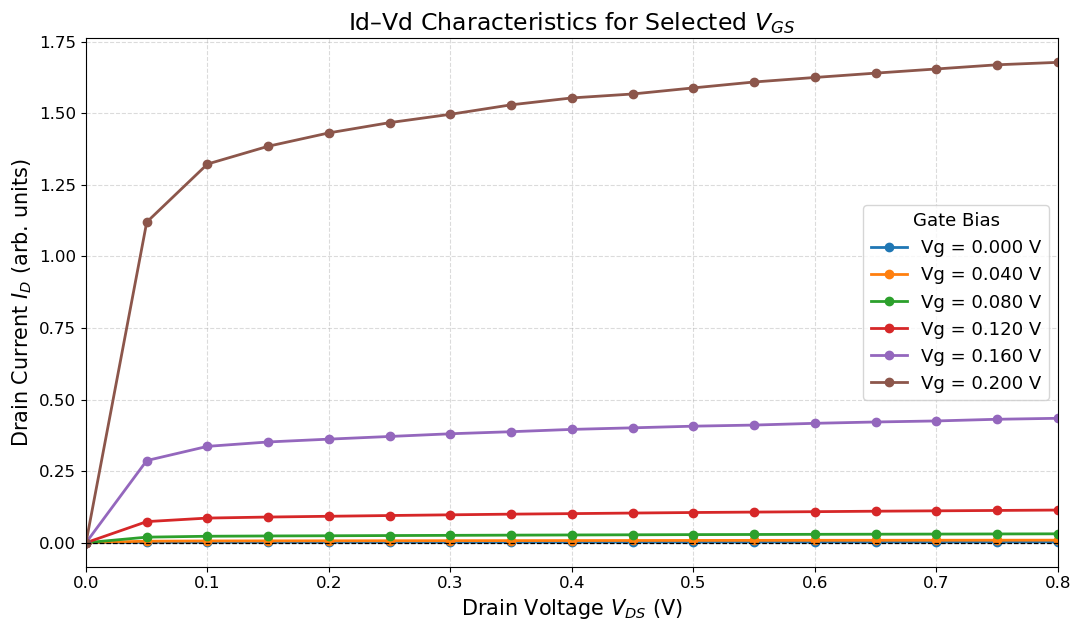

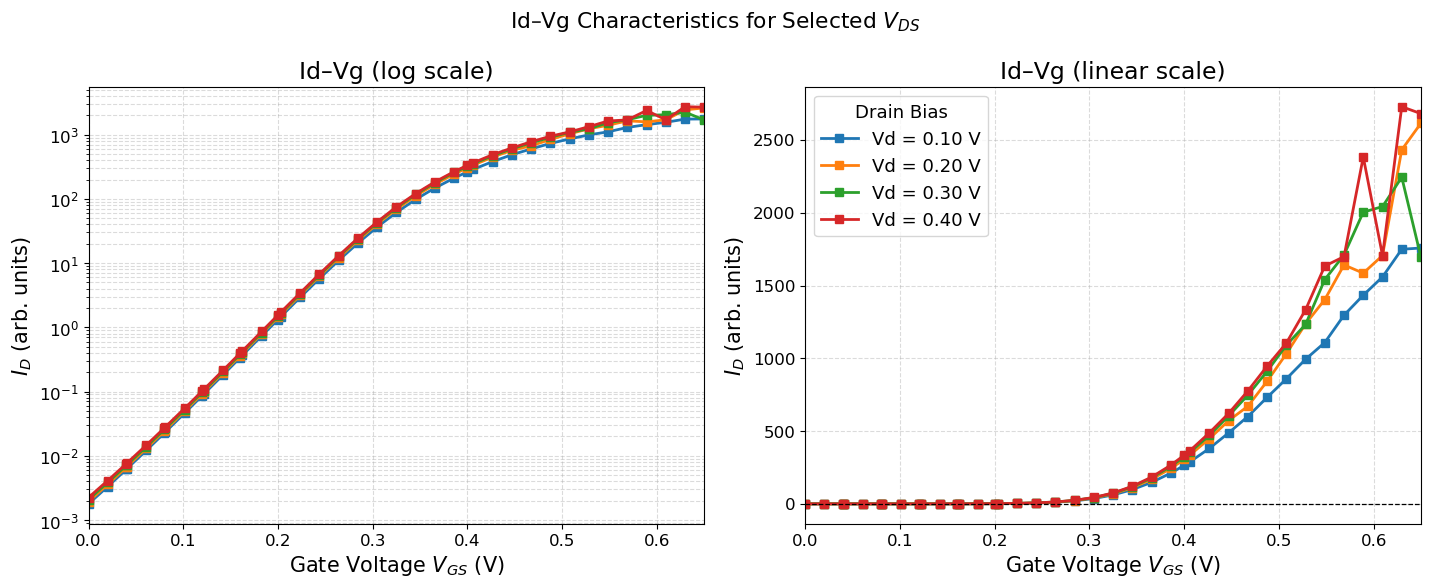

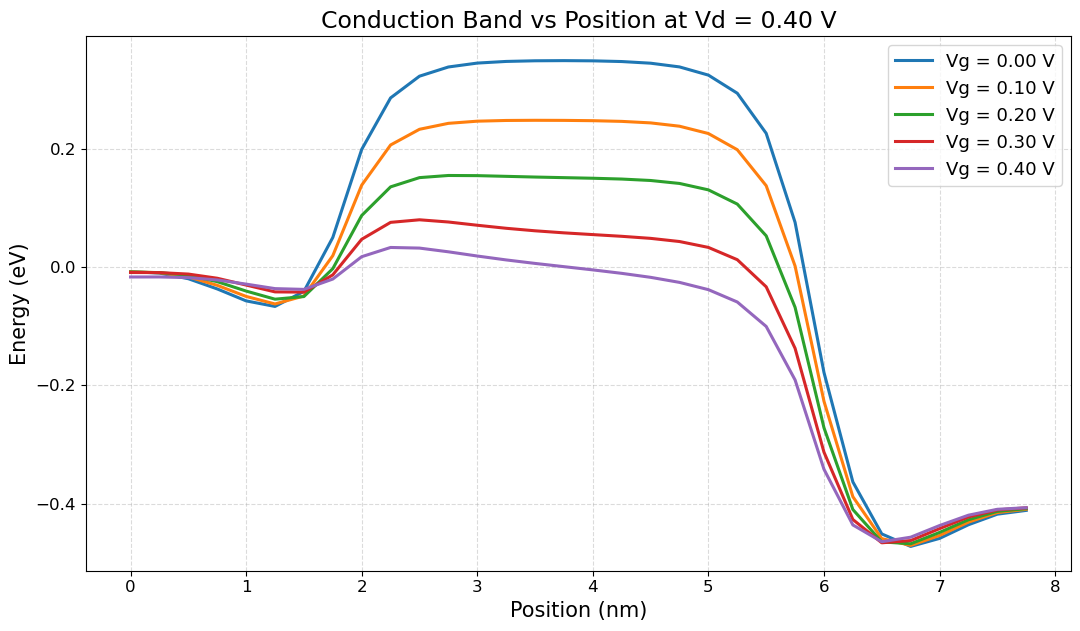

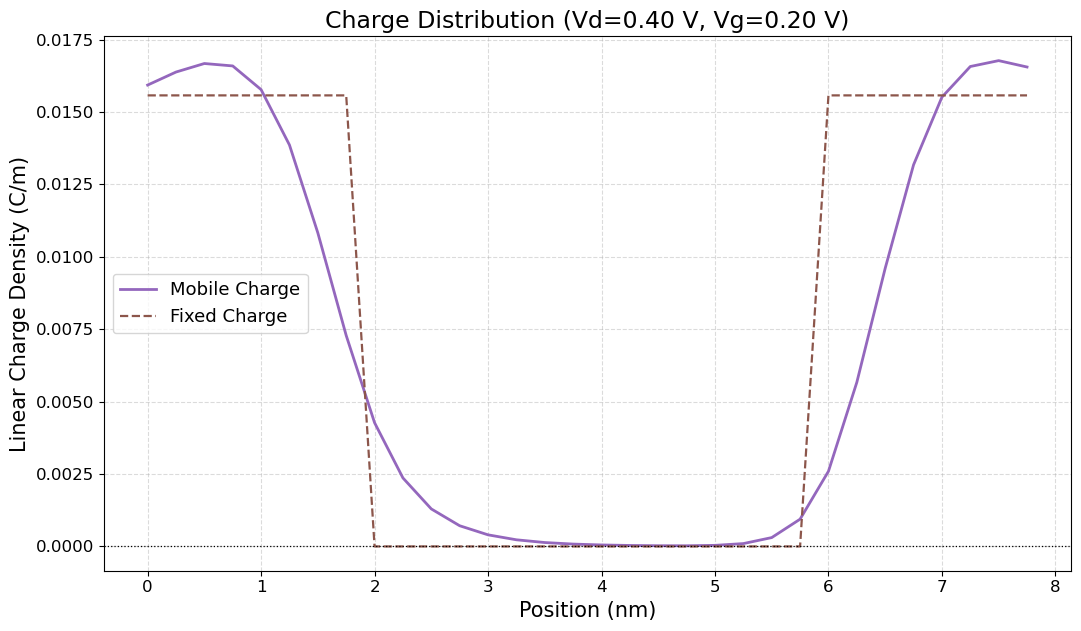

In [38]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plots_dir = Path("plots/nanotransistor")
plots_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 13,
        "axes.titlesize": 17,
        "axes.labelsize": 15,
        "legend.fontsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

ds = solver_instance.ds
Vds_sim = ds.Vds  # includes 0 V
Vgs = ds.Vgs

current_label = "arb. units"  # ds.II uses a model-specific prefactor; not guaranteed to be Amps as-is


def find_vd_index(value: float) -> int:
    return int(np.argmin(np.abs(Vds_sim - value)))


def find_vg_index(value: float) -> int:
    return int(np.argmin(np.abs(Vgs - value)))


# --- Id-Vd sweeps (include Vd=0 point) ---
# Requested Vg measurement points: 0, 0.04, 0.08, 0.12, 0.16, 0.20 V
selected_vg_values = [0.00, 0.04, 0.08, 0.12, 0.16, 0.20]
fig, ax = plt.subplots(figsize=(11, 6.5))
for vg in selected_vg_values:
    vg_idx = find_vg_index(vg)
    currents = ds.II[: len(Vds_sim), vg_idx]
    ax.plot(Vds_sim, currents, marker="o", linewidth=2, label=f"Vg = {Vgs[vg_idx]:.3f} V")
ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
ax.set_xlim(0.0, float(Vds_sim.max()))
ax.set_xlabel("Drain Voltage $V_{DS}$ (V)")
ax.set_ylabel(f"Drain Current $I_D$ ({current_label})")
ax.set_title("Id–Vd Characteristics for Selected $V_{GS}$")
ax.grid(True, which="both", linestyle="--", alpha=0.45)
ax.legend(title="Gate Bias")
fig.tight_layout()
fig.savefig(plots_dir / "id_vs_vd_selected.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Id-Vg sweeps: log scale (left) + linear (right) ---
# Note: per request, exclude Vd = 0 curve from this plot.
selected_vd_values = [0.10, 0.20, 0.30, 0.40]
I_floor = 1e-18  # avoids log(0)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14.5, 6.0), sharex=True)
for vd in selected_vd_values:
    vd_idx = find_vd_index(vd)
    currents = ds.II[vd_idx, : len(Vgs)]
    axL.semilogy(
        Vgs,
        np.maximum(np.abs(currents), I_floor),
        marker="s",
        linewidth=2,
        label=f"Vd = {Vds_sim[vd_idx]:.2f} V",
    )
    axR.plot(Vgs, currents, marker="s", linewidth=2, label=f"Vd = {Vds_sim[vd_idx]:.2f} V")
for ax in (axL, axR):
    ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    ax.set_xlim(0.0, float(Vgs.max()))
    ax.set_xlabel("Gate Voltage $V_{GS}$ (V)")
    ax.grid(True, which="both", linestyle="--", alpha=0.45)
axL.set_ylabel(f"$I_D$ ({current_label})")
axR.set_ylabel(f"$I_D$ ({current_label})")
axL.set_title("Id–Vg (log scale)")
axR.set_title("Id–Vg (linear scale)")
axR.legend(title="Drain Bias", loc="best")
fig.suptitle("Id–Vg Characteristics for Selected $V_{DS}$")
fig.tight_layout()
fig.savefig(plots_dir / "id_vs_vg_selected_log_and_linear.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Conduction band profiles vs position for multiple gate biases at Vd = 0.40 V ---
vd_fixed_for_Ec = 0.40
selected_vg_for_Ec = [0.0, 0.10, 0.20, 0.30, 0.40]
vd_idx = find_vd_index(vd_fixed_for_Ec)
positions_nm = ds.x * 1e9
fig, ax = plt.subplots(figsize=(11, 6.5))
for vg in selected_vg_for_Ec:
    vg_idx = find_vg_index(vg)
    Ec_profile_eV = ds.EEc[vd_idx, vg_idx, :] / ds.q
    ax.plot(positions_nm, Ec_profile_eV, linewidth=2.2, label=f"Vg = {Vgs[vg_idx]:.2f} V")
ax.set_xlabel("Position (nm)")
ax.set_ylabel("Energy (eV)")
ax.set_title(f"Conduction Band vs Position at Vd = {Vds_sim[vd_idx]:.2f} V")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "conduction_band_vs_vg.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Charge density profile for a representative operating point ---
config_charge = (vd_fixed_for_Ec, 0.20)
vd_idx_charge = find_vd_index(config_charge[0])
vg_idx_charge = find_vg_index(config_charge[1])
charge_profile = ds.q * ds.nn[vd_idx_charge, vg_idx_charge, :]
doping_charge = ds.q * ds.NB
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(positions_nm, charge_profile, linewidth=2, color="#9467bd", label="Mobile Charge")
ax.plot(positions_nm, doping_charge, linewidth=1.6, color="#8c564b", linestyle="--", label="Fixed Charge")
ax.axhline(0.0, color="black", linestyle=":", linewidth=0.9)
ax.set_xlabel("Position (nm)")
ax.set_ylabel("Linear Charge Density (C/m)")
ax.set_title(f"Charge Distribution (Vd={config_charge[0]:.2f} V, Vg={config_charge[1]:.2f} V)")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "charge_profile.png", dpi=300, bbox_inches="tight")
plt.show()


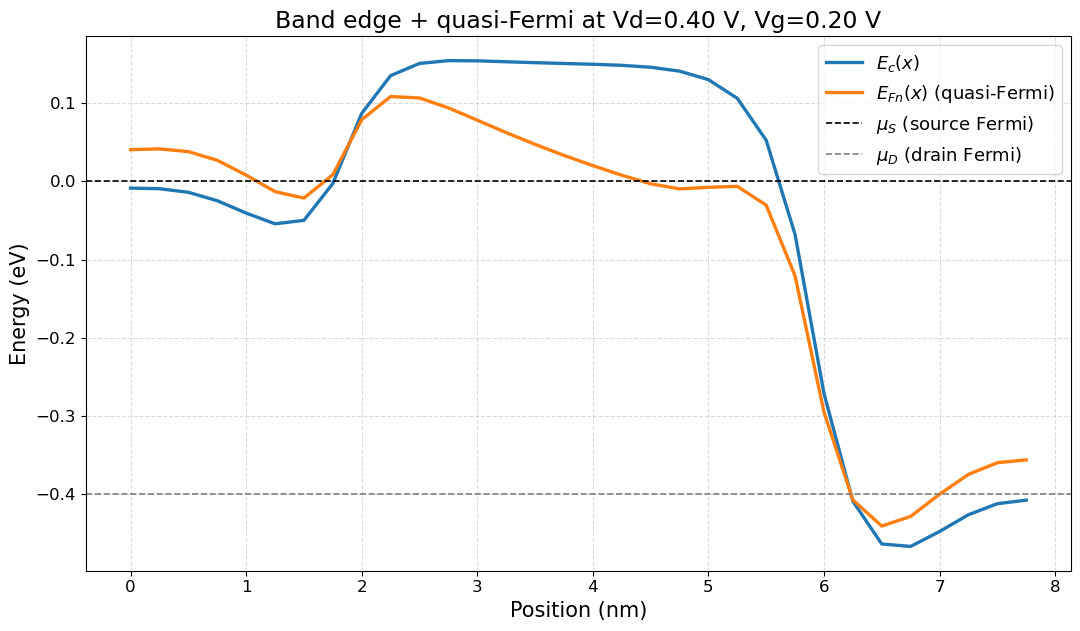

In [39]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ds = solver_instance.ds
positions_nm = ds.x * 1e9

# Pick a bias point to visualize
vd_plot = 0.40
vg_plot = 0.20

vd_idx = int(np.argmin(np.abs(ds.Vds - vd_plot)))
vg_idx = int(np.argmin(np.abs(ds.Vgs - vg_plot)))

Ec_eV = ds.EEc[vd_idx, vg_idx, :] / ds.q
Efn_eV = ds.EFn[vd_idx, vg_idx, :] / ds.q

# Contact electrochemical potentials used by NEGF (in eV)
mu_s = 0.0
mu_d = -float(ds.Vds[vd_idx])

plots_dir = Path("plots/nanotransistor")
plots_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(positions_nm, Ec_eV, linewidth=2.4, label=r"$E_c(x)$")
ax.plot(positions_nm, Efn_eV, linewidth=2.4, label=r"$E_{Fn}(x)$ (quasi-Fermi)")
ax.axhline(mu_s, color="black", linestyle="--", linewidth=1.2, label=r"$\mu_S$ (source Fermi)")
ax.axhline(mu_d, color="gray", linestyle="--", linewidth=1.2, label=r"$\mu_D$ (drain Fermi)")

ax.set_xlabel("Position (nm)")
ax.set_ylabel("Energy (eV)")
ax.set_title(f"Band edge + quasi-Fermi at Vd={ds.Vds[vd_idx]:.2f} V, Vg={ds.Vgs[vg_idx]:.2f} V")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "Ec_Efn_mu_overlay.png", dpi=300, bbox_inches="tight")
plt.show()


Bias point: Vd=0.400 V, Vg=0.200 V
Ec - muS: min=-0.468 eV, max=0.155 eV
Efn(FD-consistent) - muS: min=-0.442 eV, max=0.109 eV
Efn(FD-consistent) - Ec: min=-0.151 eV, max=0.053 eV
n/Nc: min=2.910e-03, max=2.154e+00


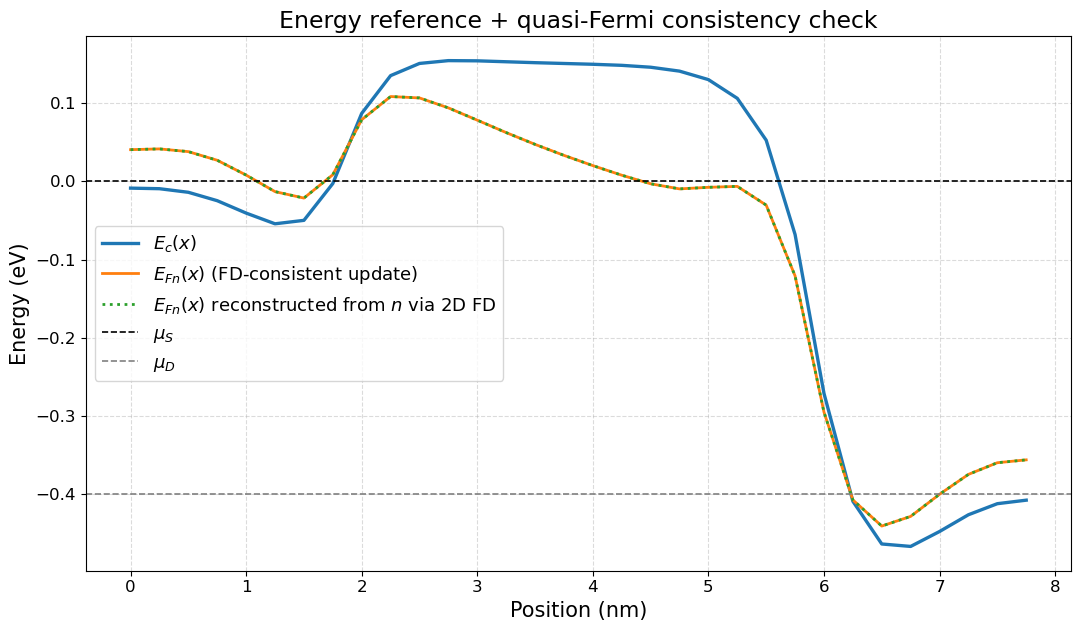

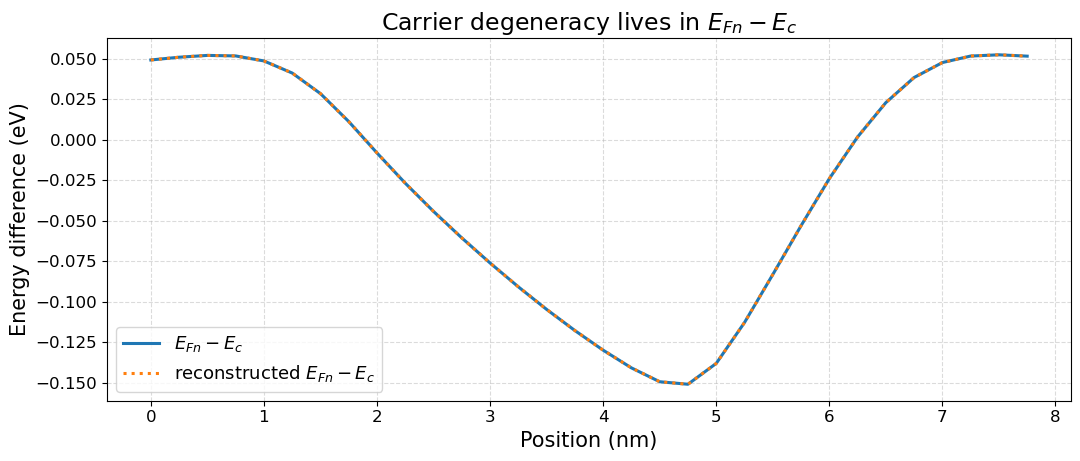

In [37]:
# Diagnostics: quasi-Fermi update consistency with Poisson charge model
import numpy as np
import matplotlib.pyplot as plt

ds = solver_instance.ds
positions_nm = ds.x * 1e9

vd_plot = 0.40
vg_plot = 0.20
vd_idx = int(np.argmin(np.abs(ds.Vds - vd_plot)))
vg_idx = int(np.argmin(np.abs(ds.Vgs - vg_plot)))

mu_s = 0.0
mu_d = -float(ds.Vds[vd_idx])

Ec_eV = ds.EEc[vd_idx, vg_idx, :] / ds.q
Efn_fd_eV = ds.EFn[vd_idx, vg_idx, :] / ds.q
n = ds.nn[vd_idx, vg_idx, :].astype(float)

# Reconstruct an Efn consistent with the 2D sheet-density relation used in Poisson wrapper:
# n = Nc * log(1 + exp(eta)), eta = (Efn - Ec)/(kT)
Nc = float(ds.Nc)
kT_eV = float(ds.kbT / ds.q)
with np.errstate(over="ignore", invalid="ignore"):
    x = np.clip(n / Nc, 0.0, None)
    eta = np.empty_like(x)
    large = x > 50.0
    eta[large] = x[large]
    eta[~large] = np.log(np.expm1(x[~large]) + 1e-300)
Efn_recon_eV = Ec_eV + kT_eV * eta

dEc_muS = Ec_eV - mu_s
dEfn_muS = Efn_fd_eV - mu_s
dEfnEc = Efn_fd_eV - Ec_eV

print(f"Bias point: Vd={ds.Vds[vd_idx]:.3f} V, Vg={ds.Vgs[vg_idx]:.3f} V")
print(f"Ec - muS: min={dEc_muS.min():.3f} eV, max={dEc_muS.max():.3f} eV")
print(f"Efn(FD-consistent) - muS: min={dEfn_muS.min():.3f} eV, max={dEfn_muS.max():.3f} eV")
print(f"Efn(FD-consistent) - Ec: min={dEfnEc.min():.3f} eV, max={dEfnEc.max():.3f} eV")
print(f"n/Nc: min={float((n/Nc).min()):.3e}, max={float((n/Nc).max()):.3e}")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(positions_nm, Ec_eV, linewidth=2.4, label=r"$E_c(x)$")
ax.plot(positions_nm, Efn_fd_eV, linewidth=2.0, label=r"$E_{Fn}(x)$ (FD-consistent update)")
ax.plot(positions_nm, Efn_recon_eV, linewidth=2.0, linestyle=":", label=r"$E_{Fn}(x)$ reconstructed from $n$ via 2D FD")
ax.axhline(mu_s, color="black", linestyle="--", linewidth=1.2, label=r"$\mu_S$")
ax.axhline(mu_d, color="gray", linestyle="--", linewidth=1.2, label=r"$\mu_D$")
ax.set_xlabel("Position (nm)")
ax.set_ylabel("Energy (eV)")
ax.set_title("Energy reference + quasi-Fermi consistency check")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(positions_nm, Efn_fd_eV - Ec_eV, linewidth=2.2, label=r"$E_{Fn} - E_c$")
ax.plot(positions_nm, Efn_recon_eV - Ec_eV, linewidth=2.2, linestyle=":", label=r"reconstructed $E_{Fn} - E_c$")
ax.set_xlabel("Position (nm)")
ax.set_ylabel("Energy difference (eV)")
ax.set_title(r"Carrier degeneracy lives in $E_{Fn}-E_c$")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend()
fig.tight_layout()
plt.show()
